# Guide to model building and running with SPyice for biogeochemical model

Demonstrates a simple example for a freezing sea ice model with heat-salinity-nutrient transport, gravity drainage, radiation and microalgae growth along with other default settings of initial conditions of 265K at the top boundary and Salinity of 34ppt choosing constant fixed Dirichlet boundary conditions. For the one phase distinct interface system where sea water is at melt temperature of 271.25K.

<img src="../../images/seaicemodel.png" width="500">


#### Import Packages

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime

%matplotlib inline
from omegaconf import OmegaConf

from spyice.utils import create_output_directory
from spyice.postprocess import Analysis, VisualiseModel
from spyice.utils import ConfigSort
from spyice.models import SeaIceModel
from spyice.preprocess import PreProcess

#### Define Inputs and Project Output paths

In [2]:
# creates a OmegaConf object from a dictionary for fast testing only for parameters: constants, dt, S_IC, iter_max, dz
constants_dict = {
    "constants": {"constants": "real"},
    "dt": {"dt": 47},
    "S_IC": {"S_IC": "S34"},
    "iter_max": {"iter_max": 10000},
    "dz": {"dz": 0.05},
}
config_raw = OmegaConf.create(constants_dict)
config = ConfigSort.getconfig_dataclass(config_raw, config_type="jupyter")

# choose your output directory
base_dir = Path.cwd()
output_base_dir = Path(base_dir, "output")
# Current date-time string
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_base_dir = Path(output_base_dir, timestamp)
wo_hydra_dir = Path(output_base_dir, "without_hydra")
out_dir_final = create_output_directory(wo_hydra_dir, config.initial_salinity.S_IC, "2", "0.01", "47", "10000", "example")

### Preprocessing 

In [3]:
# preprocess the data
preprocess_data, userinput_data = PreProcess.get_variables(config_raw, out_dir_final)

Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.


### Model settings

for more info on all the model parameters have a look at the documentation: [userinput](https://starry-phoenix.github.io/spyice-thesis/build/html/api/spyice.parameters.user_input.html)

<img src="../../images/seaicemodel_algae_layers.png" width="250">

In [4]:
# choose the diffusion only equation for heat diffusion without the influence of salinity and physical properties for algae layers
userinput_data.is_diffusiononly_equation = False
userinput_data.is_salinity_equation = True
userinput_data.is_algae_equation = True
userinput_data.is_radiation_equation = True
userinput_data.algae_model_BAL_type = "all"  # choice between "all" or "single"

In [5]:
# change dz, dt and time iterations
# simulation time = dt * (time iterations)
userinput_data.grid_resolution_dz = 0.05
userinput_data.grid_timestep_dt = 47
userinput_data.max_iterations = 10000

In [6]:
# update preprocess data class with new userinput data
preprocess_data = PreProcess.update_preprocess_dataclass(preprocess_data, userinput_data)

Time step set to: 47s
Updated Initial & Boundary Conditions...


### Run model

Running model...
Model run complete and Ready for Analysis.
Running error analysis...
Calculating errors...
Residuals exported successfully.


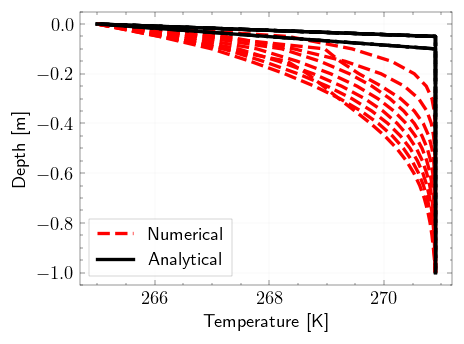

In [7]:
# run the model
results_data = SeaIceModel.get_results(preprocess_data, userinput_data)
analysis_data = Analysis.get_error_results(
            t_k_diff=results_data.t_k_diff,
            t_stefan_diff=results_data.t_stefan_diff,
            residual=results_data.residual_voller_all,
            temperature_mushy=results_data.t_k_iter_all,
            phi_mushy=results_data.all_phi_iter_all,
            salinity_mushy=results_data.s_k_iter_all,
            output_dir=out_dir_final,
        )

### Visualization of Model:
for more info on other visualization options look at:  [visualize model](https://starry-phoenix.github.io/spyice-thesis/build/html/api/spyice.postprocess.visualise_model.html)

In [8]:
model_visualization_object = VisualiseModel(
    user_input_dataclass=userinput_data,
    results_dataclass=results_data,
    error_analysis_dataclass=analysis_data,
)

Visualisation object created...


Plotting Temperature heatmap...


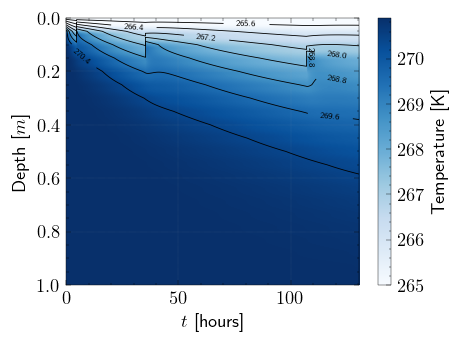

In [9]:
model_visualization_object.plot_temperature_heatmap(savefig=True, export_csv=False, show=True)

Plotting Salinity heatmap...


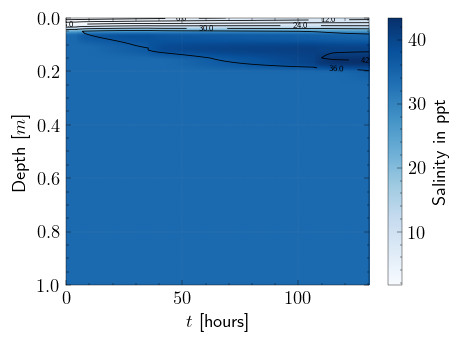

In [10]:
model_visualization_object.plot_salinity_heatmap(savefig=True, show=True)

Plotting nutrient concentration of all layers: heatmap...


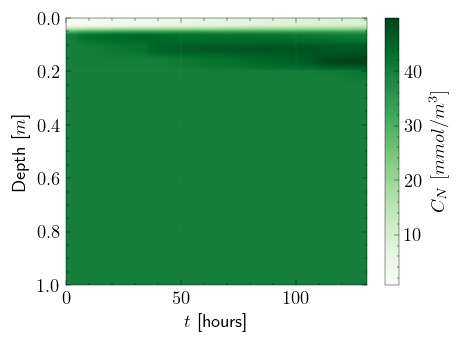

In [11]:
model_visualization_object.plot_nutrient_concentration_multiplelayers(savefig=True, show=True)

Plotting algae radiation multiple layers...


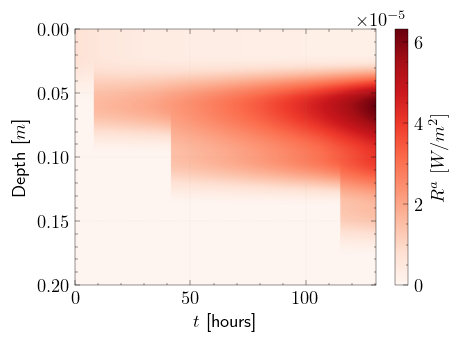

In [12]:
model_visualization_object.plot_radiation_algae_multiplelayers(savefig=True, show=True)

Plotting carbon concentration multiple layers...


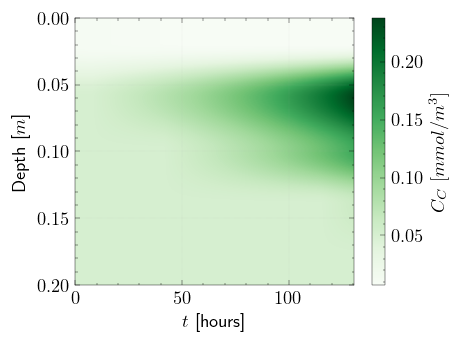

In [13]:
model_visualization_object.plot_carbon_concentration_multiplelayers(savefig=True, show=True)